# 04 - Đánh giá và trực quan hóa

Notebook này tạo các biểu đồ đơn giản để trình bày kết quả của Isolation Forest và Random Forest.

## Bước 0 - Cấu hình đường dẫn local hoặc Google Colab

Nếu chạy trên Colab, hãy đặt project tại `/content/drive/MyDrive/bot-detection-project`.

In [1]:
from pathlib import Path
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/bot-detection-project')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: d:\Data mining\AnomalyDetection-main


In [2]:
if IN_COLAB:
    %pip install -q -r "{PROJECT_ROOT / 'requirements.txt'}"

## Bước 1 - Tải mô hình và dữ liệu test

In [3]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

test_df = pd.read_csv(PROCESSED_DIR / 'test_data.csv')
X_test = test_df.drop(columns=['label'])
y_test = test_df['label'].astype(int)

# 1. Log transform skewed count features
X_test_log = X_test.copy()
skewed_cols = ["followers_count", "friends_count", "statuses_count", "favourites_count", "followers_friends_ratio"]
for col in skewed_cols:
    if col in X_test_log.columns:
        X_test_log[col] = np.log1p(X_test_log[col].clip(lower=0))

# 2. Load scalers and imputers
imputer = joblib.load(MODELS_DIR / 'imputer.pkl')
scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
imputer_iso = joblib.load(MODELS_DIR / 'imputer_iso.pkl')
scaler_iso = joblib.load(MODELS_DIR / 'scaler_iso.pkl')
isolation_forest = joblib.load(MODELS_DIR / 'isolation_forest.pkl')
random_forest = joblib.load(MODELS_DIR / 'random_forest.pkl')

# 3. Transform test data for RF (all 20 features)
X_test_imputed_rf = pd.DataFrame(imputer.transform(X_test_log), columns=X_test.columns, index=X_test.index)
X_test_scaled_rf = pd.DataFrame(scaler.transform(X_test_imputed_rf), columns=X_test.columns, index=X_test.index)

# 4. Transform test data for ISO (7 features)
iso_features = ["followers_count", "friends_count", "followers_friends_ratio", "statuses_count", "favourites_count", "account_age_days", "tweets_per_day"]
X_test_iso = X_test_log[iso_features].copy()
X_test_imputed_iso = pd.DataFrame(imputer_iso.transform(X_test_iso), columns=iso_features, index=X_test.index)
X_test_scaled_iso = pd.DataFrame(scaler_iso.transform(X_test_imputed_iso), columns=iso_features, index=X_test.index)

print(f'Đã tải dữ liệu test RF: {X_test_scaled_rf.shape}')
print(f'Đã tải dữ liệu test ISO: {X_test_scaled_iso.shape}')

Đã tải dữ liệu test RF: (2103, 31)
Đã tải dữ liệu test ISO: (2103, 7)


## Bước 2 - Tính chỉ số đánh giá

In [4]:
iso_pred = np.where(isolation_forest.predict(X_test_scaled_iso) == -1, 1, 0)
iso_score = -isolation_forest.decision_function(X_test_scaled_iso)
rf_pred = random_forest.predict(X_test_scaled_rf)
rf_score = random_forest.predict_proba(X_test_scaled_rf)[:, 1]

def metric_row(name, y_pred, y_score):
    return {
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
    }

results = {
    'Isolation Forest': metric_row('Isolation Forest', iso_pred, iso_score),
    'Random Forest': metric_row('Random Forest', rf_pred, rf_score),
}

comparison_df = pd.DataFrame([
    {
        'Mô hình': name,
        'Accuracy': val['Accuracy'],
        'Precision': val['Precision'],
        'Recall': val['Recall'],
        'F1': val['F1'],
        'AUC': val['AUC'],
    }
    for name, val in results.items()
])
display(comparison_df.round(4))

,Mô hình,Accuracy,Precision,Recall,F1,AUC
0,Isolation Forest,0.8226,0.9675,0.7607,0.8517,0.9603
1,Random Forest,0.9862,0.9943,0.9851,0.9897,0.9966


## Bước 3 - Biểu đồ cột so sánh chỉ số

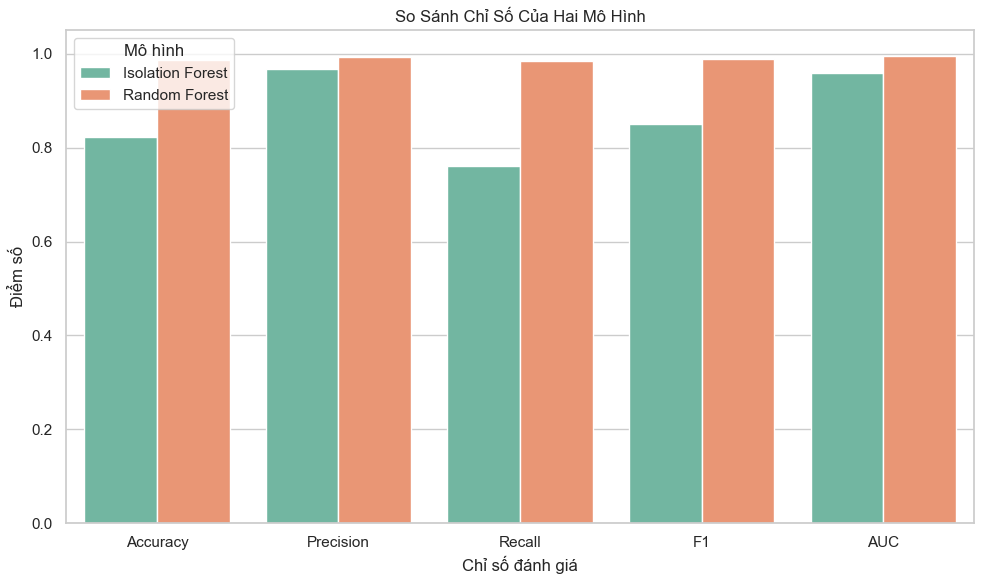

In [5]:
long_df = comparison_df.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Điểm số')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=long_df, x='Chỉ số', y='Điểm số', hue='Mô hình', palette='Set2', ax=ax)
ax.set_title('So Sánh Chỉ Số Của Hai Mô Hình')
ax.set_xlabel('Chỉ số đánh giá')
ax.set_ylabel('Điểm số')
ax.set_ylim(0, 1.05)
ax.legend(title='Mô hình')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_metrics_comparison.png', dpi=150)
plt.show()

## Bước 4 - Ma trận nhầm lẫn

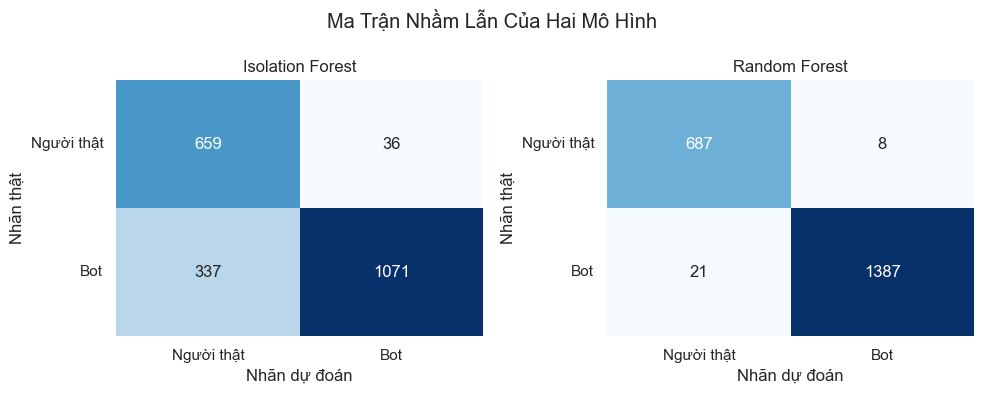

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, prediction in [
    (axes[0], 'Isolation Forest', iso_pred),
    (axes[1], 'Random Forest', rf_pred),
]:
    matrix = confusion_matrix(y_test, prediction)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Nhãn dự đoán')
    ax.set_ylabel('Nhãn thật')
    ax.set_xticklabels(['Người thật', 'Bot'])
    ax.set_yticklabels(['Người thật', 'Bot'], rotation=0)
fig.suptitle('Ma Trận Nhầm Lẫn Của Hai Mô Hình')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

## Bước 5 - Đường cong ROC

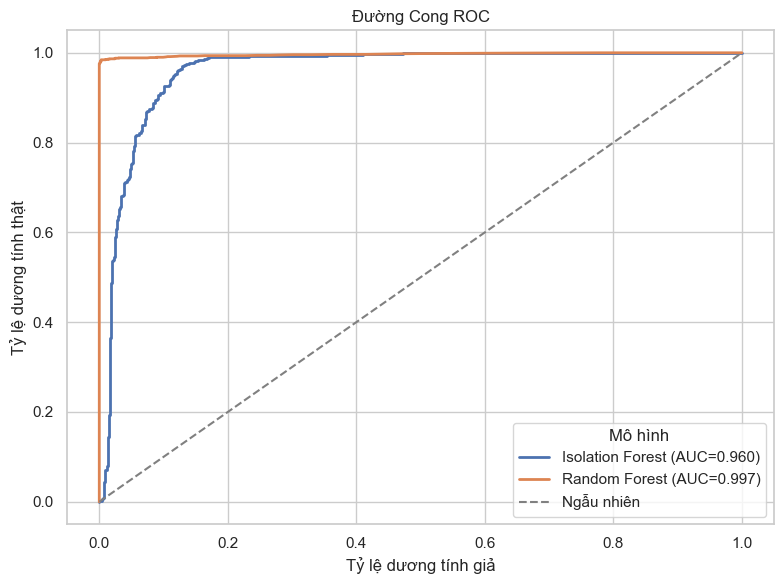

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, score in [('Isolation Forest', iso_score), ('Random Forest', rf_score)]:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ngẫu nhiên')
ax.set_title('Đường Cong ROC')
ax.set_xlabel('Tỷ lệ dương tính giả')
ax.set_ylabel('Tỷ lệ dương tính thật')
ax.legend(title='Mô hình')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'roc_curve.png', dpi=150)
plt.show()

## Bước 6 - Độ quan trọng đặc trưng của Random Forest

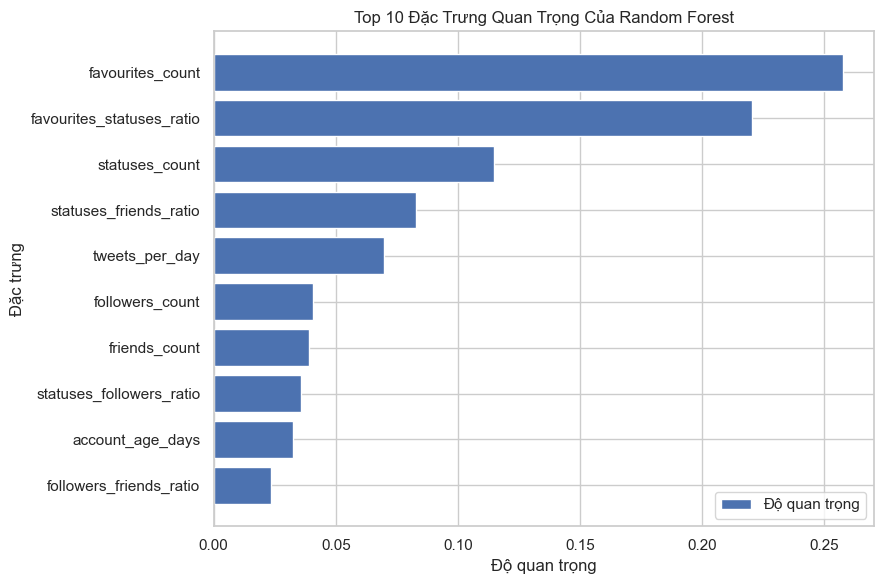

In [8]:
importances = pd.Series(random_forest.feature_importances_, index=X_test.columns).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index, importances.values, label='Độ quan trọng')
ax.set_title('Top 10 Đặc Trưng Quan Trọng Của Random Forest')
ax.set_xlabel('Độ quan trọng')
ax.set_ylabel('Đặc trưng')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150)
plt.show()

## Bước 7 - Phân phối điểm bất thường (Isolation Forest)

Biểu đồ phân phối điểm bất thường dưới đây so sánh điểm bất thường (anomaly score) giữa tài khoản bot và người thật. Biểu đồ này giải thích trực quan cách ngưỡng phân loại (threshold) được xác định dựa trên tỷ lệ nhiễm (contamination = 0.35) và cho thấy sự chồng lấn (overlap) giữa hai phân phối, lý giải tại sao độ chính xác và AUC của Isolation Forest thấp hơn so với Random Forest.

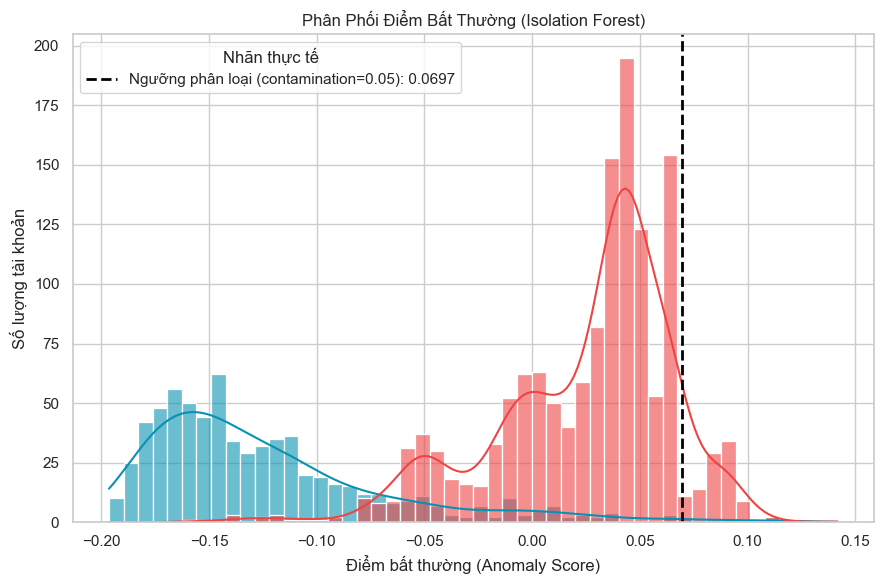

In [9]:
contamination = isolation_forest.contamination
threshold = np.percentile(iso_score, 100 - (contamination * 100))

fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(x=iso_score, hue=y_test.map({0: 'Người thật', 1: 'Bot'}), kde=True, bins=50, ax=ax, palette={'Người thật': '#0891b2', 'Bot': '#ef4444'}, alpha=0.6)
ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Ngưỡng phân loại (contamination={contamination}): {threshold:.4f}')
ax.set_title('Phân Phối Điểm Bất Thường (Isolation Forest)')
ax.set_xlabel('Điểm bất thường (Anomaly Score)')
ax.set_ylabel('Số lượng tài khoản')
ax.legend(title='Nhãn thực tế')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'anomaly_score_dist.png', dpi=150)
plt.show()

## Kết luận

- Isolation Forest đóng vai trò phát hiện hồ sơ bất thường và không thay thế bộ phân loại bot.
- Random Forest là mô hình phân loại chính vì cho xác suất bot và có thể giải thích bằng độ quan trọng đặc trưng.
- Khi hai mô hình cùng cảnh báo, tài khoản được xếp vào nhóm rủi ro cao.